=== AND Gate Training ===

Epoch 1 (AND)
Input: [0 0], yi=1, di=0, error=-1, updated weights=[0. 0.], bias=-0.1
Input: [0 1], yi=0, di=0, error=0, updated weights=[0. 0.], bias=-0.1
Input: [1 0], yi=0, di=0, error=0, updated weights=[0. 0.], bias=-0.1
Input: [1 1], yi=0, di=1, error=1, updated weights=[0.1 0.1], bias=0.0

Epoch 2 (AND)
Input: [0 0], yi=1, di=0, error=-1, updated weights=[0.1 0.1], bias=-0.1
Input: [0 1], yi=1, di=0, error=-1, updated weights=[0.1 0. ], bias=-0.2
Input: [1 0], yi=0, di=0, error=0, updated weights=[0.1 0. ], bias=-0.2
Input: [1 1], yi=0, di=1, error=1, updated weights=[0.2 0.1], bias=-0.1

Epoch 3 (AND)
Input: [0 0], yi=0, di=0, error=0, updated weights=[0.2 0.1], bias=-0.1
Input: [0 1], yi=1, di=0, error=-1, updated weights=[0.2 0. ], bias=-0.2
Input: [1 0], yi=1, di=0, error=-1, updated weights=[0.1 0. ], bias=-0.30000000000000004
Input: [1 1], yi=0, di=1, error=1, updated weights=[0.2 0.1], bias=-0.20000000000000004

Epoch 4 (AND)
Input: [0 0], yi=0, 

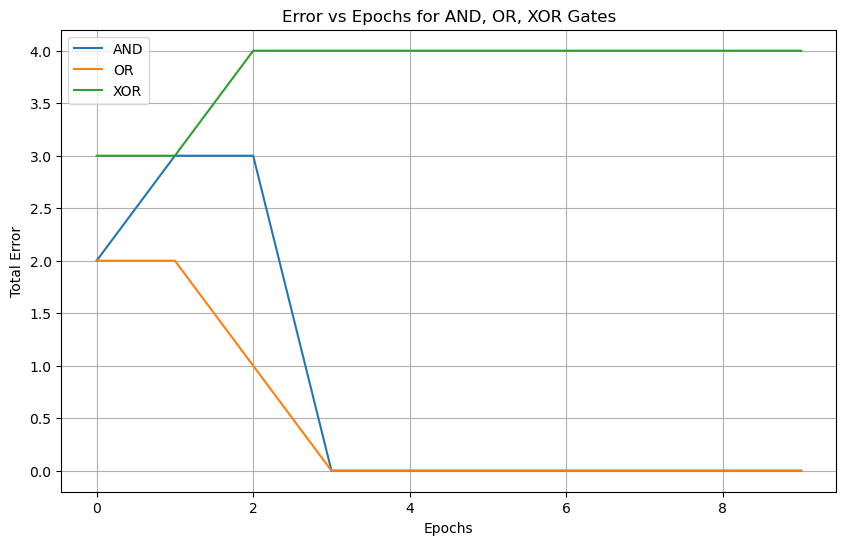

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Step activation
def step(x):
    return 1 if x >= 0 else 0

# Perceptron training
def perceptron_train(X, D, lr=0.1, epochs=10, gate_name="Gate"):
    w = np.zeros(X.shape[1])   # weights
    b = 0                      # bias
    errors = []                # track error per epoch
    
    for epoch in range(epochs):
        total_error = 0
        print(f"\nEpoch {epoch+1} ({gate_name})")
        for i in range(len(X)):
            xi = X[i]
            di = D[i]
            net = np.dot(w, xi) + b
            yi = step(net)
            error = di - yi
            total_error += abs(error)   # accumulate error
            
            # Update rule
            w = w + lr * error * xi
            b = b + lr * error
            
            print(f"Input: {xi}, yi={yi}, di={di}, error={error}, updated weights={w}, bias={b}")
        
        errors.append(total_error)
    return w, b, errors

# Training data for gates
X = np.array([[0,0],[0,1],[1,0],[1,1]])

# AND gate
print("=== AND Gate Training ===")
D_and = np.array([0,0,0,1])
w_and, b_and, err_and = perceptron_train(X, D_and, lr=0.1, epochs=10, gate_name="AND")

# OR gate
print("\n=== OR Gate Training ===")
D_or = np.array([0,1,1,1])
w_or, b_or, err_or = perceptron_train(X, D_or, lr=0.1, epochs=10, gate_name="OR")

# XOR gate (will fail with single layer perceptron)
print("\n=== XOR Gate Training (Fails) ===")
D_xor = np.array([0,1,1,0])
w_xor, b_xor, err_xor = perceptron_train(X, D_xor, lr=0.1, epochs=10, gate_name="XOR")

# Plot error vs epochs
plt.figure(figsize=(10,6))
plt.plot(err_and, label="AND")
plt.plot(err_or, label="OR")
plt.plot(err_xor, label="XOR")
plt.xlabel("Epochs")
plt.ylabel("Total Error")
plt.title("Error vs Epochs for AND, OR, XOR Gates")
plt.legend()
plt.grid(True)
plt.show()

=== AND Gate with Sigmoid ===

Epoch 1
Input: [0 0 0], yi=0.500, di=0, error=-0.500, updated weights=[0. 0. 0.], bias=-0.050
Input: [0 0 1], yi=0.488, di=0, error=-0.488, updated weights=[ 0.          0.         -0.04875026], bias=-0.099
Input: [0 1 0], yi=0.475, di=0, error=-0.475, updated weights=[ 0.         -0.04753325 -0.04875026], bias=-0.146
Input: [0 1 1], yi=0.440, di=0, error=-0.440, updated weights=[ 0.         -0.09149863 -0.09271565], bias=-0.190
Input: [1 0 0], yi=0.453, di=0, error=-0.453, updated weights=[-0.04525807 -0.09149863 -0.09271565], bias=-0.236
Input: [1 0 1], yi=0.408, di=0, error=-0.408, updated weights=[-0.0860281  -0.09149863 -0.13348567], bias=-0.276
Input: [1 1 0], yi=0.388, di=0, error=-0.388, updated weights=[-0.12487377 -0.13034431 -0.13348567], bias=-0.315
Input: [1 1 1], yi=0.331, di=1, error=0.669, updated weights=[-0.05797021 -0.06344075 -0.06658211], bias=-0.248

Epoch 2
Input: [0 0 0], yi=0.438, di=0, error=-0.438, updated weights=[-0.05797021 -

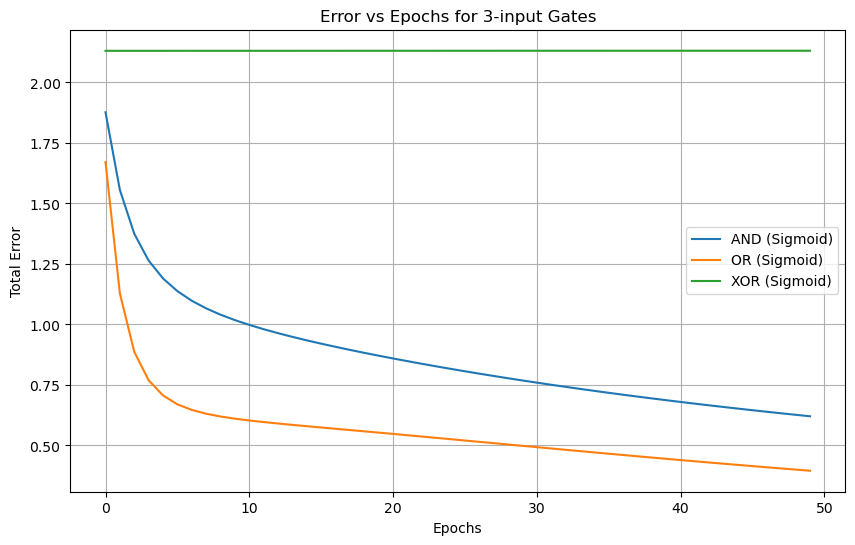

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Activation functions
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def bipolar_sigmoid(x):
    return (2 / (1 + np.exp(-x))) - 1

def tanh_act(x):
    return np.tanh(x)

# Perceptron training
def train_perceptron(X, D, activation, lr=0.1, epochs=50):
    w = np.zeros(X.shape[1])   # weights
    b = 0                      # bias
    errors = []

    for epoch in range(epochs):
        total_error = 0
        print(f"\nEpoch {epoch+1}")
        for i in range(len(X)):
            xi = X[i]
            di = D[i]
            net = np.dot(w, xi) + b
            yi = activation(net)
            error = di - yi
            total_error += error**2

            # Update rule
            w = w + lr * error * xi
            b = b + lr * error

            print(f"Input: {xi}, yi={yi:.3f}, di={di}, error={error:.3f}, updated weights={w}, bias={b:.3f}")

        errors.append(total_error)
    return w, b, errors

# Training data for 3-input gates
X = np.array([[0,0,0],[0,0,1],[0,1,0],[0,1,1],
              [1,0,0],[1,0,1],[1,1,0],[1,1,1]])

# Desired outputs
D_and = np.array([0,0,0,0,0,0,0,1])   # AND
D_or  = np.array([0,1,1,1,1,1,1,1])   # OR
D_xor = np.array([0,1,1,0,1,0,0,1])   # XOR (not linearly separable)

# Train with sigmoid
print("=== AND Gate with Sigmoid ===")
w_and, b_and, err_and = train_perceptron(X, D_and, sigmoid)

print("\n=== OR Gate with Sigmoid ===")
w_or, b_or, err_or = train_perceptron(X, D_or, sigmoid)

print("\n=== XOR Gate with Sigmoid (Fails) ===")
w_xor, b_xor, err_xor = train_perceptron(X, D_xor, sigmoid)

# Plot error vs epochs
plt.figure(figsize=(10,6))
plt.plot(err_and, label="AND (Sigmoid)")
plt.plot(err_or, label="OR (Sigmoid)")
plt.plot(err_xor, label="XOR (Sigmoid)")
plt.xlabel("Epochs")
plt.ylabel("Total Error")
plt.title("Error vs Epochs for 3-input Gates")
plt.legend()
plt.grid(True)
plt.show()